In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import sqlite3

In [2]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
          select name 
          from sqlite_master
          where type='table'
          
"""
tables = pd.read_sql(sql_query , conn)

for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name} ", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")
conn.close()


Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [3]:
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query , conn)
    print("Column:")
    print(columns['name'].tolist())

conn.close()



Table Name: db_customer
Column:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Column:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Column:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [4]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [5]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [6]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


Changes i want in Data

In [7]:
# 1) rename the name column 
# 2) drop the column like interest and pincode 
# 3) changing the dob datatype 
# 4) data standardization of gender column 
# 5) fix the country missung values 

Rename the Name column 

In [8]:

df_db_customer.rename(columns={'name': 'customer_name'}, inplace=True)
df_db_customer


,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [9]:
print(df_db_customer.columns.tolist())

['customerid', 'customer_name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']


Drop the column like Interest and Pincode 

In [10]:
#df_db_customer.drop(df_db_customer.columns[6:],axis=1)
df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)  



In [11]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer_name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


 Changing the dob datatype

In [12]:
df_db_customer['dob']= pd.to_datetime(df_db_customer['dob'])

In [13]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


Data Standardization of Gender column

In [14]:
df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [15]:
df_db_customer['gender'] =  df_db_customer['gender'].replace({'Men' : 'Male' , 'Women' : 'Female'})

In [16]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)


Fix the Country Missung values 

In [17]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [18]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,None,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,None,Kathmandu
9,Nepal,Kathmandu


In [19]:
#state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
#df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))



state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()


df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [20]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob



Now Subscription table

In [21]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [22]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [23]:
dat_col = ['subscription_start_date' , 'renewal_date' ,'cancellation_date' ]
df_db_subscription[dat_col]=df_db_subscription[dat_col].apply(pd.to_datetime)

In [24]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


Now Support Table

In [25]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [26]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [27]:
df_db_support.drop(columns = ['col_1','comment'], inplace = True)

In [28]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 420.0+ bytes


In [29]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])


In [30]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


Data Analysis and Feature Engineering

Using the existing column create new one 

In [31]:

df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0 )

In [32]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


First Fix Support Table Duplicates then Merge

In [33]:
df = (df_db_subscription
                .merge(df_db_customer, on  = 'customerid' , how='left')
                .merge(df_db_support, on  = 'customerid' ,how = 'left') )

In [34]:
df.shape

(23, 20)

In [35]:
df_db_subscription.shape

(21, 12)

In [36]:
df_db_customer['customerid'].nunique()

21

In [37]:
df_db_subscription['customerid'].nunique()

21

In [38]:
df_db_support['customerid'].nunique()

7

In [39]:
df_db_support['customerid'].size

9

In [40]:
df_db_support['customer_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [41]:
df_db_support

,customerid,complaint_date,escalations,csat_score,customer_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [42]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep = 'last')

In [43]:
df_db_support['customerid'].size

7

Merge Dataframe 

In [44]:
df = (df_db_subscription
                .merge(df_db_customer, on  = 'customerid' , how='left')
                .merge(df_db_support, on  = 'customerid' ,how = 'left') )

In [45]:
df.shape

(21, 21)

Data Analysis and Features engineering 

In [46]:
df.to_csv('exported_churn_data.csv' , index = False )

Data Analysis


In [47]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'customer_count'],
      dtype='object')

In [48]:
churn_rate = df['churn_flag'].mean() * 100

print("Churn Rate =", round(churn_rate, 2), "%")

Churn Rate = 28.57 %


Retension rate

In [49]:
retention_rate = 100 - churn_rate

print("Retention Rate =", round(retention_rate, 2), "%")

Retention Rate = 71.43 %


Churn by plan type

In [50]:
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(3).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic          60.000
1   Premium          14.286
2  Standard          22.222


In [51]:
churn_by_state = (
    df.groupby('state')
      .agg(
          churn_rate_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
          total_revenue=('monthly_charges', 'sum'),
          user_count=('customerid', 'count')
      )
      .reset_index()
)

print(churn_by_state)

           state  churn_rate_pct  total_revenue  user_count
0          Delhi           25.00          52.96           4
1      Karnataka          100.00          20.98           2
2      Kathmandu            0.00          20.98           2
3    Maharashtra            0.00          50.97           3
4      Meghalaya           66.67          42.97           3
5       Nagaland            0.00          22.99           1
6      Rajasthan            0.00          36.98           2
7      Telangana           50.00          30.98           2
8  Uttar Pradesh            0.00         115.98           2


In [52]:
print(df.columns)

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'customer_count'],
      dtype='object')


In [53]:
churn_by_subscription = (
    df.groupby('subscription_type')
      .agg(
          churn_rate_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
          total_revenue=('monthly_charges', 'sum'),
          user_count=('customerid', 'count')
      )
      .reset_index()
)

print(churn_by_subscription)

  subscription_type  churn_rate_pct  total_revenue  user_count
0           Organic            0.00         145.91           9
1              Paid           16.67         174.94           6
2          Refferal           83.33          74.94           6


Average Revenue per User

In [54]:
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  18.85


In [55]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'customer_count'],
      dtype='object')

Average Customer Tenure

In [56]:
today = pd.Timestamp.today()

df['Tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['Tenure_days'].mean()

print("Avg Tenure (Days) =", round(avg_tenure, 0))


Avg Tenure (Days) = 1509.0


In [57]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'customer_count',
       'Tenure_days'],
      dtype='object')

Revenue at risk - Revenue lost from churned users 

In [58]:
revenue_at_risk = df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Revenue at risk ( Rs Lakhs)=", revenue_at_risk)

Revenue at risk ( Rs Lakhs)= 73.94


In [59]:
df.head(5)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,customer_count,Tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,1968.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,1353.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,2643.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,419.0


Esclation Rate

In [60]:
escalation_rate = (df['escalations'] == "Y").mean() * 100
print("Escalation Rate = ", round(escalation_rate, 2), "%")

Escalation Rate =  19.05 %


Average complaint per user 

In [61]:
df['customer_count'].sum()/ df['customerid'].nunique()

np.float64(0.42857142857142855)

Correlation Esclation VS  Churn

In [62]:
corr_df = df[['escalations', 'churn_flag']].dropna().copy()
corr_df['escalations'] = np.where(corr_df['escalations'] == 'Y', 1, 0)

correlation = corr_df['escalations'].corr(corr_df['churn_flag'])
print("Correlation between escalation vs churn is =", round(correlation, 2))


Correlation between escalation vs churn is = 0.47


Churn Risk - Create a column using existing column

In [63]:
conditions = [
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) & (df['churn_score'] < 70),(df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unkown')

In [64]:
df[['churn_score' , 'churn_risk']].head()

,churn_score,churn_risk
0,12,low
1,91,high
2,34,low
3,8,low
4,88,high


4) Data Visualization using Mathplotlib

In [65]:
df_visual= df.copy()

In [66]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'customer_count',
       'Tenure_days', 'churn_risk'],
      dtype='object')

Monthly Churn Trend (Time series KPI)

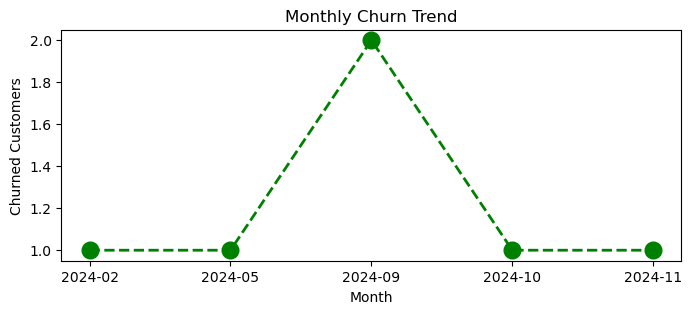

In [67]:
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values,  color='green', marker='o', linestyle='dashed',  linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

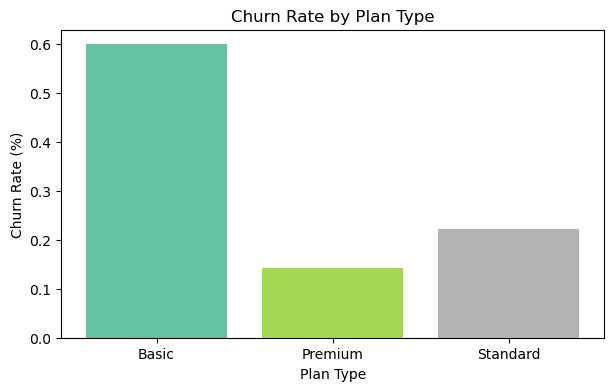

In [68]:
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.show()

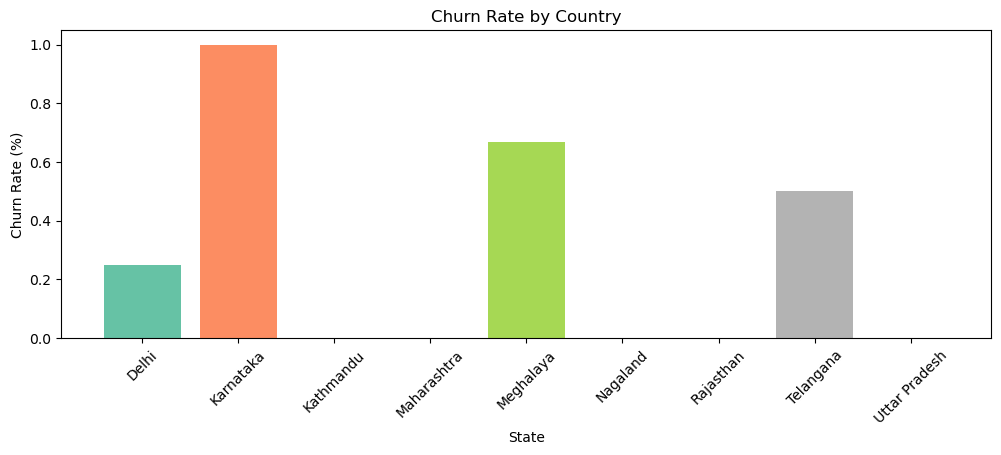

In [69]:
churn_plan = df_visual.groupby('state')['churn_flag'].mean()
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))
plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Country')
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

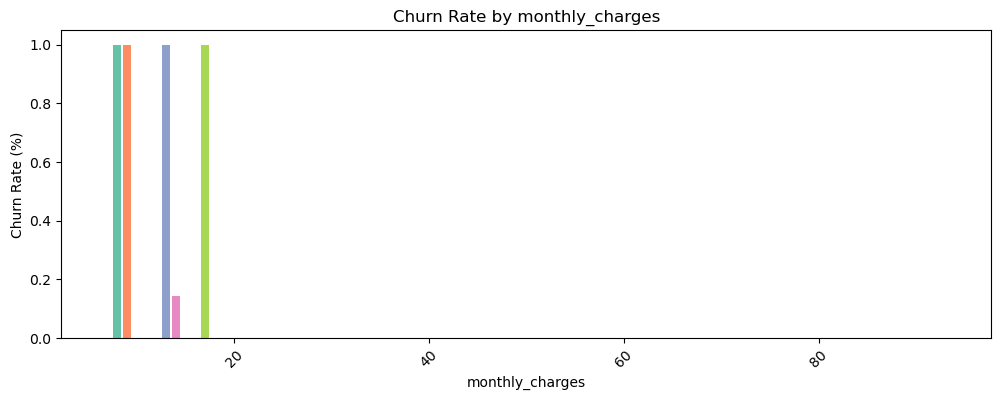

In [72]:
churn_plan = df_visual.groupby('monthly_charges')['churn_flag'].mean()
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))
plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by monthly_charges')
plt.xlabel('monthly_charges')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

5) Visualization Using Seaborn

Heatmap

In [74]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'customer_count',
       'Tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [92]:
df_encoded = df_visual[['plan_type', 'contract_type','churn_score' , 'churn_flag', 'churn_risk' , 'escalations']]
df_encoded['escalations'] = df_encoded['escalations'].map({'Y': 1}).fillna(0).astype(int)


In [93]:
df_encoded

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1
5,Standard,Annual,22,0,low,0
6,Basic,Monthly,79,1,high,0
7,Premium,Annual,5,0,low,0
8,Standard,Monthly,34,0,low,0
9,Basic,Annual,41,0,low,0


In [100]:
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].copy()

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes
df_encoded['escalations'] = df_encoded['escalations'].map({'Y': 1}).fillna(0).astype(int)



In [101]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

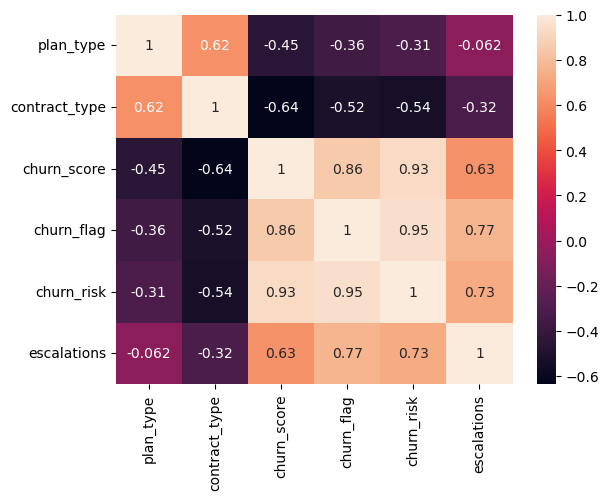

In [102]:
sns.heatmap(df_encoded.corr() , annot = True)

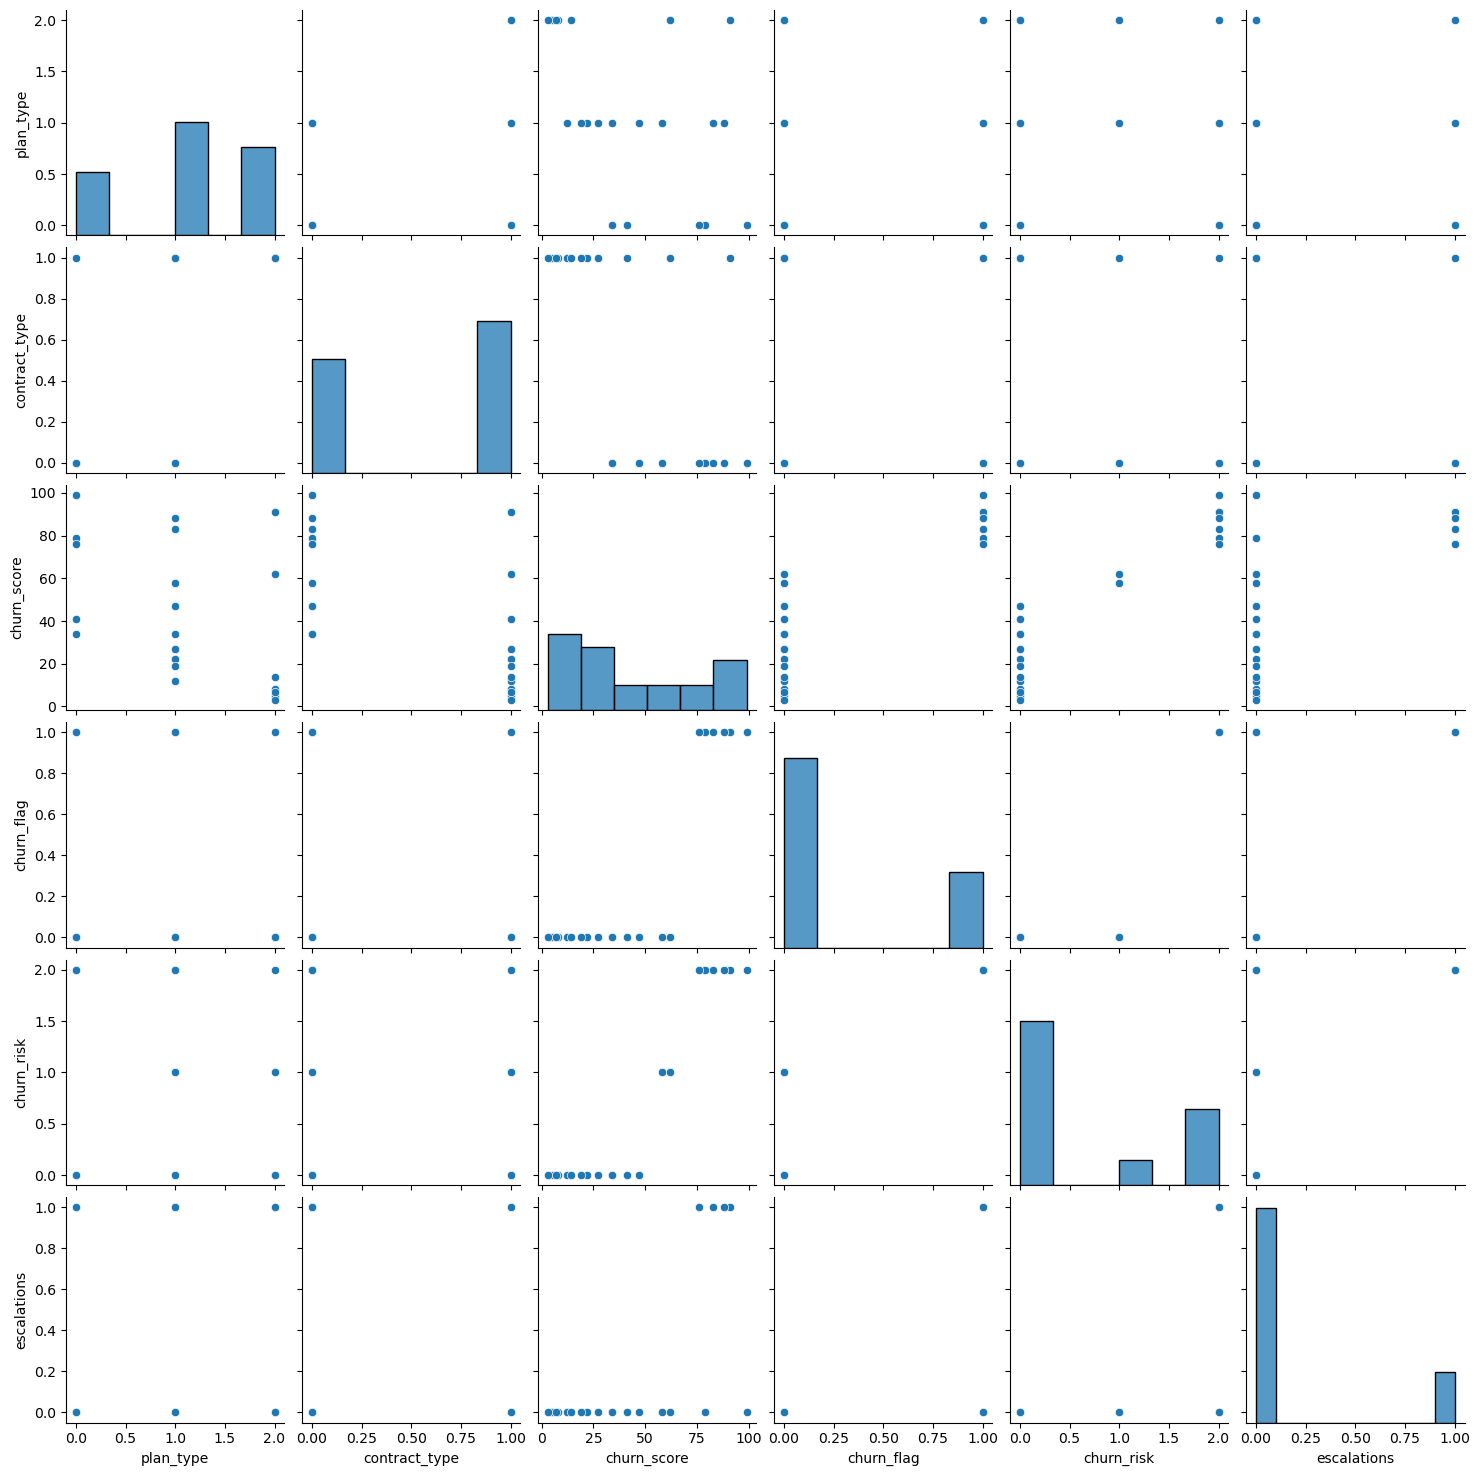

In [103]:
sns.pairplot(df_encoded)

In [108]:
sns.catplot(data= df_visual, 
    x='plan_type',
    y='monthly_charge',
    hue='gender',
    col='churn_risk')

ValueError: Could not interpret value `monthly_charge` for `y`. An entry with this name does not appear in `data`.

In [105]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'customer_count',
       'Tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')